# Stage 0. Data Harmonization and EDA

Notebook ini membangun manifest situs nail dari metadata_en.csv dan foto kuku statis di folder unas, menurunkan label anemik memakai ambang dewasa sesuai gender, lalu menampilkan eksplorasi distribusi hemoglobin, severity, dan demografi. Dataset berbagi populasi dan metadata yang sama persis dengan situs palm (Valles-Coral dkk. 2025, UNSM Tarapoto, Peru), namun berbeda dari palm yang bersumber video, folder unas berisi foto statis JPG satu per partisipan sehingga tidak ada tahap frame selection sebelum manifest ini.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import pandas as pd
import matplotlib.pyplot as plt

from configs import paths
from src.common import manifest as manifest_utils
from src.sites.nail import data

print(paths.dataset_root("nail"))

/home/praktikan/projects/Azril/hemavision/dataset/nail


## Build Manifest

Setiap baris manifest mewakili satu partisipan dengan satu foto kuku. Severity diturunkan dari kolom one-hot Normal/Mild/Moderate lalu dipetakan ke kosakata severity bersama proyek (Non-Anemic/Mild/Moderate/Severe), sedangkan label anemik diturunkan dari ambang hemoglobin dewasa sesuai gender, konsisten dengan pendekatan situs konjungtiva dan palm. Baris tanpa kategori keparahan jelas atau tanpa foto yang berhasil diunggah dilewati otomatis.

In [2]:
manifest = data.build_manifest(save=False)
print("shape", manifest.shape)
manifest.head()

Nail melewati 106 baris (foto tidak valid atau Hb/Age tidak plausibel): ['ID002', 'ID026(age=nan)', 'ID027(age=nan)', 'ID030', 'ID038', 'ID041', 'ID047', 'ID056']
shape (803, 13)


,uid,dataset,site,roi_path,raw_path,mask_path,roi_precropped,hb_gdl,age_years,gender,severity,anemic,hb_threshold
0,nail_ID001,nail_valles_coral,nail,,/home/praktikan/projects/Azril/hemavision/data...,,False,13.6,25.0,M,Non-Anemic,0,13.0
1,nail_ID003,nail_valles_coral,nail,,/home/praktikan/projects/Azril/hemavision/data...,,False,14.3,23.0,M,Non-Anemic,0,13.0
2,nail_ID004,nail_valles_coral,nail,,/home/praktikan/projects/Azril/hemavision/data...,,False,11.5,23.0,F,Mild,1,12.0
3,nail_ID005,nail_valles_coral,nail,,/home/praktikan/projects/Azril/hemavision/data...,,False,10.8,24.0,F,Moderate,1,12.0
4,nail_ID006,nail_valles_coral,nail,,/home/praktikan/projects/Azril/hemavision/data...,,False,13.7,23.0,M,Non-Anemic,0,13.0


## Dataset Composition

Ringkasan jumlah sampel, keseimbangan label anemik, distribusi severity, dan statistik demografi. Total foto unas yang terunggah dan terverifikasi lengkap adalah 826 file (551 Normal, 202 Mild, 73 Moderate); jumlah baris manifest bisa sedikit lebih kecil setelah filter plausibilitas Hb dan umur, bukan karena file hilang seperti pada palm.

In [3]:
data.summarize(manifest)

Total sampel: 803

Distribusi label anemik:
anemic
0    541
1    262

Distribusi severity:
severity
Non-Anemic    541
Mild          191
Moderate       71

Distribusi gender:
gender
F    490
M    313

Statistik hemoglobin:
min        8.60
median    12.60
max       17.00
mean      12.77

Statistik umur tahun:
min       16.0
median    20.0
max       30.0


## Hemoglobin Distribution

Distribusi kadar hemoglobin pada populasi dewasa muda Peru. Garis putus-putus menandai ambang anemia dewasa WHO, 13 g/dL untuk laki-laki dan 12 g/dL untuk perempuan.

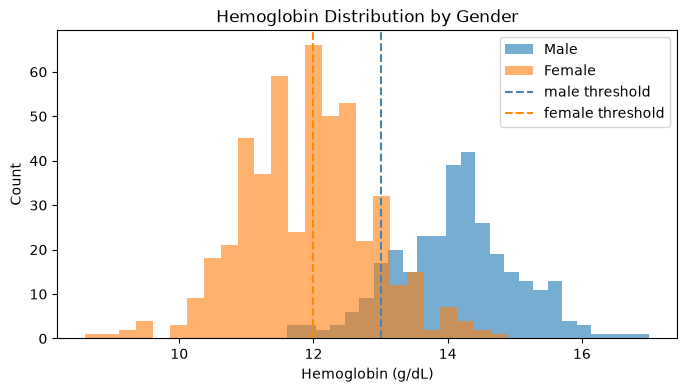

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(manifest.loc[manifest["gender"] == "M", "hb_gdl"].dropna(), bins=25, alpha=0.6, label="Male")
ax.hist(manifest.loc[manifest["gender"] == "F", "hb_gdl"].dropna(), bins=25, alpha=0.6, label="Female")
ax.axvline(13.0, color="steelblue", linestyle="--", label="male threshold")
ax.axvline(12.0, color="darkorange", linestyle="--", label="female threshold")
ax.set_xlabel("Hemoglobin (g/dL)")
ax.set_ylabel("Count")
ax.set_title("Hemoglobin Distribution by Gender")
ax.legend()
plt.show()

## Class Balance and Severity

Keseimbangan label anemia dan distribusi tiga kelas severity yang tersedia pada dataset ini (Non-Anemic, Mild, Moderate, tanpa kasus Severe). Kelas Moderate diperkirakan minoritas keras (sekitar 73 sampel, 8.8 persen dari 826), pola imbalance yang sama seperti palm.

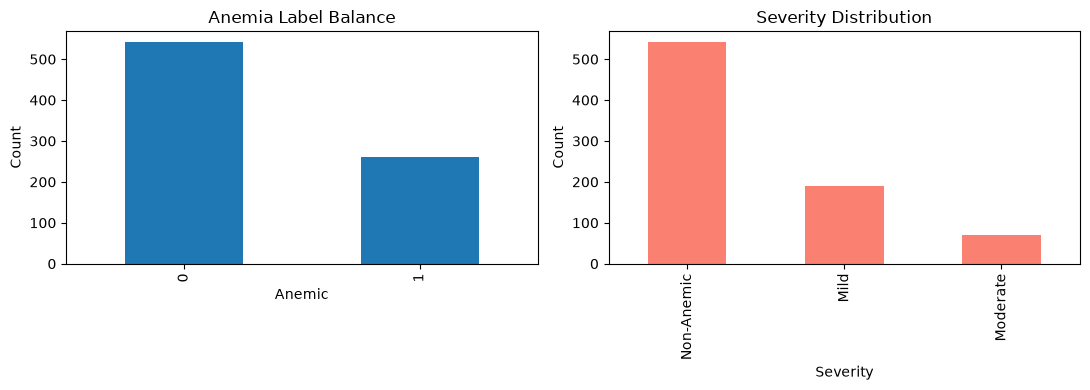

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

manifest["anemic"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Anemia Label Balance")
axes[0].set_xlabel("Anemic")
axes[0].set_ylabel("Count")

severity_order = ["Non-Anemic", "Mild", "Moderate"]
manifest["severity"].value_counts().reindex(severity_order).plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("Severity Distribution")
axes[1].set_xlabel("Severity")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Stratified Patient Split

Membagi data menjadi train, validation, dan test secara terstratifikasi per label anemik. Setiap baris mewakili satu pasien sehingga pembagian ini setara dengan pembagian berbasis pasien, sama seperti situs konjungtiva dan palm.

In [6]:
manifest = manifest_utils.assign_stratified_split(manifest)
print(manifest.groupby(["dataset", "split"]).size().to_string())

dataset            split
nail_valles_coral  test     120
                   train    563
                   val      120


## Save Manifest

In [7]:
output_path = paths.outputs_dir("nail") / "manifest.csv"
manifest.to_csv(output_path, index=False)
print("manifest saved to", output_path)

manifest saved to /home/praktikan/projects/Azril/hemavision/outputs/nail/manifest.csv
